In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid size
K = 12
gamma = 0.95

START = (0, 0)
GOAL = (K-1, K-1)

ACTIONS = {
    0: (-1, 0),  # North
    1: (1, 0),   # South
    2: (0, 1),   # East
    3: (0, -1),  # West
}

def is_valid(state): #Actions that go out of bounds are forbidden (0.k)
    x, y = state
    return 0 <= x < K and 0 <= y < K

def step(state, action):
    if state == GOAL: # If you are already at the goal:you stay there forever
        return state, 0

    dx, dy = ACTIONS[action] #Computing next state . where system wants to go
    next_state = (state[0] + dx, state[1] + dy)

    if not is_valid(next_state):
        next_state = state  # if try to leave the grid → stay but still gets punished -1

    if next_state == GOAL: #if next step is reaching the goal
        reward = 2 * (K - 1)
    else:
        reward = -1

    return next_state, reward





In [ ]:
# SARSA algorithm

#PARAMETERS

alpha = 0.1      # learning rate
epsilon = 0.1    # ε-greedy exploration
episodes = 5000  # number of episodes

# Q(s,a) table       Q(s,a)=0∀s,a
Q = np.zeros((K, K, len(ACTIONS)))

#choose A from ε-greedy policy from Q
def epsilon_greedy_action(state, Q, epsilon): #This policy is used both for acting and learning
    x, y = state

    if np.random.rand() < epsilon:
        return np.random.choice(list(ACTIONS.keys()))
    else:
        return np.argmax(Q[x, y])


for ep in range(episodes):

    # (i) INIT: S ← S0
    state = START

    # (ii) choose A from ε-greedy policy
    action = epsilon_greedy_action(state, Q, epsilon)

    while state != GOAL:

        # Take action A, observe R, S'
        next_state, reward = step(state, action)

        # Choose A' from ε-greedy policy
        next_action = epsilon_greedy_action(next_state, Q, epsilon)

        x, y = state
        nx, ny = next_state

        # (iii) SARSA update rule
        Q[x, y, action] = Q[x, y, action] + alpha * (reward + gamma * Q[nx, ny, next_action] - Q[x, y, action])

        # Move forward
        state = next_state
        action = next_action


In [ ]:
# OPTIMAL POLICY FROM SARSA

policy_sarsa = np.zeros((K, K), dtype=int)

for x in range(K):
    for y in range(K):
        policy_sarsa[x, y] = np.argmax(Q[x, y])


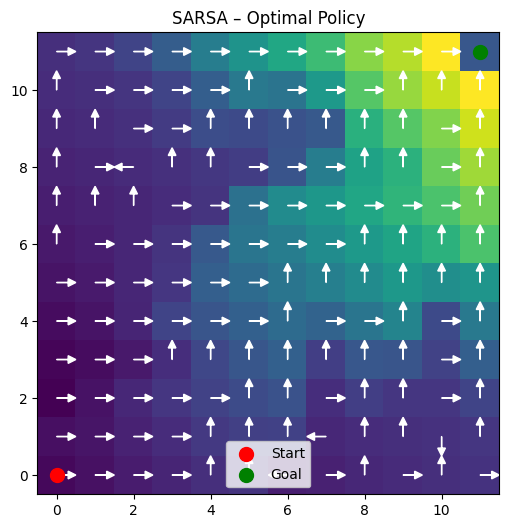

In [ ]:
def plot_policy(V, policy, title):
    plt.figure(figsize=(6, 6))
    plt.imshow(V, origin="lower", cmap="viridis")

    for x in range(K):
        for y in range(K):
            if (x, y) == GOAL:
                continue

            a = policy[x, y]
            dx, dy = ACTIONS[a]

            plt.arrow(
                y, x,
                dy * 0.3, dx * 0.3,
                head_width=0.2,
                head_length=0.2,
                color="white"
            )

    plt.scatter(START[1], START[0], c="red", s=100, label="Start")
    plt.scatter(GOAL[1], GOAL[0], c="green", s=100, label="Goal")
    plt.legend()
    plt.title(title)
    plt.show()
plot_policy(np.max(Q, axis=2), policy_sarsa, "SARSA – Optimal Policy")
